In [ ]:
import pandas as pd
import CTM

df = pd.read_csv('dft_rawcount_local_authority_id_85.csv', delimiter=',',low_memory=False,header=1,names=['count_point_id','direction_of_travel','year','count_date','hour','region_id','region_name','local_authority_id','local_authority_name','road_name','road_type','start_junction_road_name','end_junction_road_name','easting','northing','latitude','longitude','link_length_km','link_length_miles','pedal_cycles','two_wheeled_motor_vehicles','cars_and_taxis','buses_and_coaches','lgvs','hgvs_2_rigid_axle','hgvs_3_rigid_axle','hgvs_4_or_more_rigid_axle','hgvs_3_or_4_articulated_axle','hgvs_5_articulated_axle','hgvs_6_articulated_axle','all_hgvs','all_motor_vehicles']
)
filtered_df=df[(df['count_point_id']==810896) | (df['count_point_id']==57603) | (df['count_point_id']==944412)]
directions_of_travel=filtered_df['direction_of_travel'].unique()
East_travelling_df=filtered_df[filtered_df['direction_of_travel']=='E']
West_travelling_df=filtered_df[filtered_df['direction_of_travel']=='W']

def get_moving_traffic_data(df,count_point_id,type):
    filtered_df=df[df['count_point_id']==count_point_id]
    travelling_df=filtered_df[filtered_df['direction_of_travel']==type]
    return travelling_df





for type in filtered_df['direction_of_travel'].unique():
    print(type)
    directed_df=filtered_df[filtered_df['direction_of_travel']==type]
    print(get_moving_traffic_data(directed_df,57603,type)[['count_point_id','all_motor_vehicles','direction_of_travel']])
    print(get_moving_traffic_data(directed_df,810896,type)[['count_point_id','all_motor_vehicles','direction_of_travel']])
    print(get_moving_traffic_data(directed_df,944412,type)[['count_point_id','all_motor_vehicles','direction_of_travel']])
    

model=CTM()



# East_travelling_df=get_east_moving_traffic_data(df,57603)
# West_travelling_df=get_west_moving_traffic_data(df,57603)
# print(East_travelling_df[['hour','all_motor_vehicles','link_length_miles']].sort_values(by='hour'))
# print(West_travelling_df[['hour','all_motor_vehicles','direction_of_travel']].sort_values(by='hour'))




S
       count_point_id  all_motor_vehicles direction_of_travel
13919           57603                 918                   S
13920           57603                1057                   S
13922           57603                 734                   S
13923           57603                 696                   S
13926           57603                 421                   S
13928           57603                 569                   S
13930           57603                 865                   S
13933           57603                 705                   S
13935           57603                 709                   S
13938           57603                 906                   S
13939           57603                 712                   S
13941           57603                 650                   S
13944           57603                 576                   S
13946           57603                 667                   S
13948           57603                 643                   S
13951 

# testing CTM model

The time to the end cell is:  2.6865671641791042  in minutes


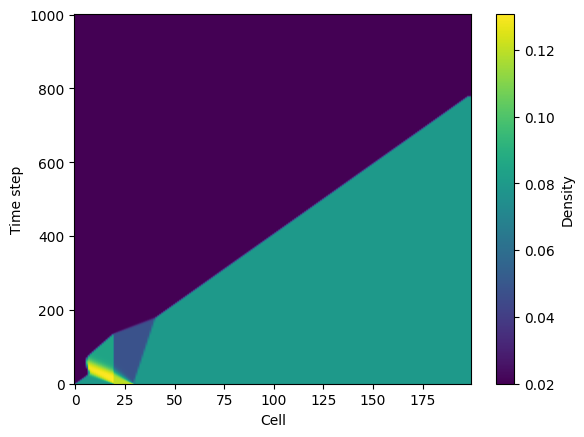

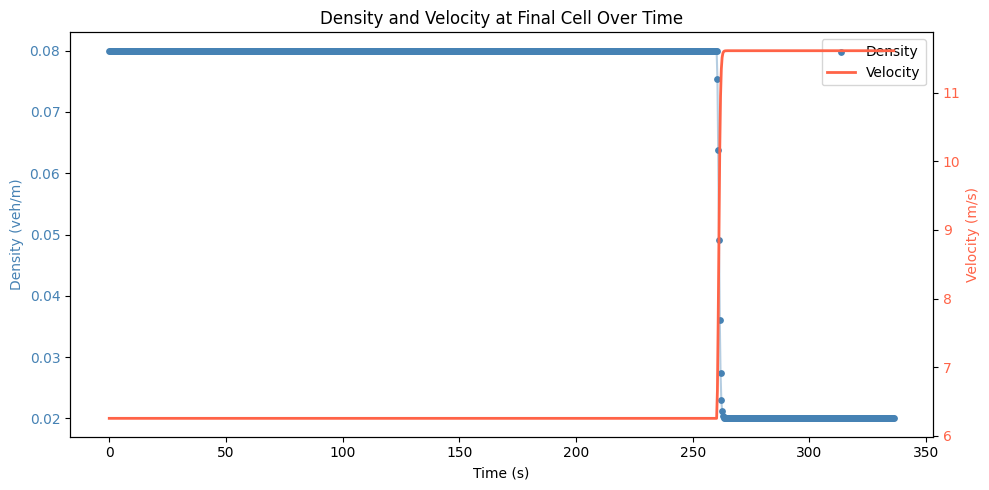

In [25]:
# Road setup
import numpy as np
import CTM
N = 200                         # number of cells
road_length = 1000              # metres
cell_widths = np.full(N, road_length / N)  # uniform 5m cells

# Traffic parameters
v_free = 13.4                     # m/s (about 108 km/h, motorway speed)
jam_density = 0.15              # vehicles per metre (1 vehicle per ~7m)
max_flow = v_free * jam_density / 4  # Greenshields peak flow

# Initial density — light traffic everywhere
density_init = np.full(N, 0.08)  # 0.02 veh/m, well below critical
density_init[20:30] = 0.12

# Inlet density — slightly higher to push traffic in
inlet_density = 0.02

model = CTM.CTM_model(cell_widths, density_init, jam_density, max_flow, v_free)
model.recursive_stepping(0, inlet_density, total_steps=1000)

time=model.travel_time(start_cell=0, end_cell=199)
try:
    print("The time to the end cell is: ",time/60," in minutes")
except:
    print("The car didn't reach the end in the given number of steps")

import matplotlib.pyplot as plt
plt.imshow(np.array(model.history), aspect='auto', origin='lower')
plt.xlabel('Cell'); plt.ylabel('Time step'); plt.colorbar(label='Density')
plt.show()

final_density=np.array(model.history)[:,-1]
final_velocity= v_free * (1 - final_density / jam_density)


fig, ax1 = plt.subplots(figsize=(10, 5))

final_cell_density = np.array(model.history)[:, -1]
final_cell_velocity = v_free * (1 - final_cell_density / jam_density)

timesteps = np.arange(len(final_cell_density)) * model.step_width  # convert to seconds

ax1.scatter(timesteps, final_cell_density, color='steelblue', s=15, label='Density')
ax1.plot(timesteps, final_cell_density, color='steelblue', alpha=0.4)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Density (veh/m)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(timesteps, final_cell_velocity, color='tomato', linewidth=2, label='Velocity')
ax2.set_ylabel('Velocity (m/s)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Density and Velocity at Final Cell Over Time')
fig.tight_layout()
plt.show()
